In [1]:
import pandas as pd

df = pd.read_json("/home/intern_fjq_2026/data/NLP/research_report/forecast_stk_20240101_20241231.jsonl", lines=True,)

In [2]:
df.head()

,ID,STOCK_CODE,STOCK_NAME,TITLE,CONTENT,REPORT_TYPE,RELIABILITY,ORGAN_NAME,AUTHOR_NAME,CREATE_DATE,...,ORGAN_RATING_CODE,ORGAN_RATING_CONTENT,GG_RATING_CODE,GG_RATING_CONTENT,TARGET_PRICE_CEILING,TARGET_PRICE_FLOOR,CURRENT_PRICE,CURRENCY,LANGUAGE,ATTENTION
0,3836861,513,丽珠集团,医药生物：5大维度盘点医疗器械2023如何走过？2024有哪些关注？,None,21,5.0,国盛证券,"张金洋,杨芳",2024-01-01 00:00:00,...,0,无,0,无,NaN,NaN,35.01,NaN,NaN,一般报告
1,3836921,538,云南白药,医药生物：5大维度盘点医疗器械2023如何走过？2024有哪些关注？,None,21,5.0,国盛证券,"张金洋,杨芳",2024-01-01 00:00:00,...,0,无,0,无,NaN,NaN,49.15,NaN,NaN,一般报告
2,3836490,786,北新建材,北新建材：股权激励业绩考核目标较高，“一体两翼”超预期推进,核心观点：\n\n 公司发布2023年股权激励计划，业绩考核目标较高，彰显公司发展信心...,22,NaN,广发证券,"邹戈,谢璐,张乾,陈伟豪",2024-01-01 00:00:00,...,177,买入,7,买入,NaN,38.27,23.36,NaN,0.0,一般报告
3,3836054,786,北新建材,北新建材：股权激励目标超预期，收购嘉宝莉稳步推进,投资要点\n\n 事件：2023年12月29日，公司发布两则重要公告：1）公司发布20...,25,NaN,德邦证券,"闫广,王逸枫",2024-01-01 00:00:00,...,622,买入,7,买入,NaN,NaN,23.36,NaN,0.0,一般报告
4,3836053,786,北新建材,北新建材：股权激励目标超预期，收购嘉宝莉稳步推进,投资要点\n\n 事件：2023年12月29日，公司发布两则重要公告：1）公司发布20...,25,NaN,德邦证券,"闫广,王逸枫",2024-01-01 00:00:00,...,622,买入,7,买入,NaN,NaN,23.36,NaN,0.0,一般报告


In [3]:
print("shape:", df.shape)
print("columns:")
print(df.columns.tolist())

shape: (273409, 32)
columns:
['ID', 'STOCK_CODE', 'STOCK_NAME', 'TITLE', 'CONTENT', 'REPORT_TYPE', 'RELIABILITY', 'ORGAN_NAME', 'AUTHOR_NAME', 'CREATE_DATE', 'REPORT_YEAR', 'REPORT_QUARTER', 'FORECAST_OR', 'FORECAST_OP', 'FORECAST_TP', 'FORECAST_NP', 'FORECAST_EPS', 'FORECAST_DPS', 'FORECAST_RD', 'FORECAST_PE', 'FORECAST_ROE', 'FORECAST_EV_EBITDA', 'ORGAN_RATING_CODE', 'ORGAN_RATING_CONTENT', 'GG_RATING_CODE', 'GG_RATING_CONTENT', 'TARGET_PRICE_CEILING', 'TARGET_PRICE_FLOOR', 'CURRENT_PRICE', 'CURRENCY', 'LANGUAGE', 'ATTENTION']


# 数据质量彻查（从第 4 个 cell 开始）

目标：彻底看清楚 `/home/intern_fjq_2026/data/NLP/research_report/forecast_stk_20240101_20241231.jsonl` 这个数据到底是什么样的。

> 前 3 个 cell 保持不变：`read_json` 加载 `df` → `df.head()` → 打印 `shape` 与 `columns`。
> 本 notebook 需要按顺序从上到下运行，后面的 cell 都依赖 `df` 与前面 cell 中定义的字段分组常量。


In [4]:
# ============================================================
# 0. 全局配置：导入、字段分组、字段含义
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

# 使用系统中文字体，避免图上中文显示为方框
plt.rcParams["font.sans-serif"] = ["WenQuanYi Micro Hei", "WenQuanYi Zen Hei", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

print("DataFrame shape:", df.shape)
print("内存占用(deep): {:.1f} MB".format(df.memory_usage(deep=True).sum() / 1024**2))

# ---- 字段分组 ----
meta_cols     = ["ID", "STOCK_CODE", "STOCK_NAME", "CREATE_DATE"]
text_cols     = ["TITLE", "CONTENT"]
report_cols   = ["REPORT_TYPE", "RELIABILITY", "ORGAN_NAME", "AUTHOR_NAME",
                 "REPORT_YEAR", "REPORT_QUARTER", "ATTENTION"]
forecast_cols = ["FORECAST_OR", "FORECAST_OP", "FORECAST_TP", "FORECAST_NP",
                 "FORECAST_EPS", "FORECAST_DPS", "FORECAST_RD", "FORECAST_PE",
                 "FORECAST_ROE", "FORECAST_EV_EBITDA"]
rating_cols   = ["ORGAN_RATING_CODE", "ORGAN_RATING_CONTENT",
                 "GG_RATING_CODE", "GG_RATING_CONTENT"]
price_cols    = ["TARGET_PRICE_CEILING", "TARGET_PRICE_FLOOR", "CURRENT_PRICE"]
cat_cols      = ["REPORT_TYPE", "ATTENTION", "RELIABILITY", "LANGUAGE", "CURRENCY"]

field_meaning = {
    "ID": "记录唯一ID",
    "STOCK_CODE": "股票代码",
    "STOCK_NAME": "股票名称",
    "TITLE": "报告标题",
    "CONTENT": "报告正文内容",
    "REPORT_TYPE": "报告类型(编码)",
    "RELIABILITY": "可靠度评分",
    "ORGAN_NAME": "发布机构",
    "AUTHOR_NAME": "分析师姓名(逗号分隔)",
    "CREATE_DATE": "报告创建日期",
    "REPORT_YEAR": "报告对应年度",
    "REPORT_QUARTER": "报告对应季度",
    "FORECAST_OR": "预测营业收入",
    "FORECAST_OP": "预测营业利润",
    "FORECAST_TP": "预测利润总额",
    "FORECAST_NP": "预测净利润",
    "FORECAST_EPS": "预测每股收益 EPS",
    "FORECAST_DPS": "预测每股股利 DPS",
    "FORECAST_RD": "预测研发费用",
    "FORECAST_PE": "预测市盈率 PE",
    "FORECAST_ROE": "预测净资产收益率 ROE",
    "FORECAST_EV_EBITDA": "预测 EV/EBITDA",
    "ORGAN_RATING_CODE": "机构评级编码",
    "ORGAN_RATING_CONTENT": "机构评级文案",
    "GG_RATING_CODE": "个股评级编码",
    "GG_RATING_CONTENT": "个股评级文案",
    "TARGET_PRICE_CEILING": "目标价上限",
    "TARGET_PRICE_FLOOR": "目标价下限",
    "CURRENT_PRICE": "当前股价",
    "CURRENCY": "币种",
    "LANGUAGE": "语言(编码)",
    "ATTENTION": "报告关注标签",
}
pd.DataFrame({"字段含义": field_meaning}).reindex(df.columns)


DataFrame shape: (273409, 32)


内存占用(deep): 824.3 MB


,字段含义
ID,记录唯一ID
STOCK_CODE,股票代码
STOCK_NAME,股票名称
TITLE,报告标题
CONTENT,报告正文内容
REPORT_TYPE,报告类型(编码)
RELIABILITY,可靠度评分
ORGAN_NAME,发布机构
AUTHOR_NAME,分析师姓名(逗号分隔)
CREATE_DATE,报告创建日期


## 1. 字段类型 / 缺失 / 唯一值总览


In [5]:
# ============================================================
# 1. 字段类型 / 缺失 / 唯一值总览
# ============================================================
overview = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "non_null": df.notna().sum(),
    "null": df.isna().sum(),
    "null_pct": (df.isna().mean() * 100).round(2),
    "n_unique": df.nunique(dropna=False),
})
overview.sort_values(["null_pct", "n_unique"], ascending=[False, False])


,dtype,non_null,null,null_pct,n_unique
CURRENCY,float64,0,273409,100.00,1
TARGET_PRICE_CEILING,float64,648,272761,99.76,175
FORECAST_OP,float64,29823,243586,89.09,13401
RELIABILITY,float64,41744,231665,84.73,7
FORECAST_RD,float64,63833,209576,76.65,1075
FORECAST_DPS,float64,72432,200977,73.51,1962
TARGET_PRICE_FLOOR,float64,76811,196598,71.91,6579
FORECAST_EV_EBITDA,float64,169766,103643,37.91,7244
FORECAST_PE,float64,214112,59297,21.69,10543
FORECAST_TP,float64,214261,59148,21.63,48999


## 2. 主键与唯一性 / 重复行


In [6]:
# ============================================================
# 2. 主键与唯一性 / 重复行
# ============================================================
print("总行数:", len(df))
print("ID 唯一性 is_unique =", df["ID"].is_unique, "| ID 唯一值数 =", df["ID"].nunique())
print("完全重复的行数 =", int(df.duplicated().sum()))
print("按 ID 分组后行数>1 的 ID 个数 =", int((df.groupby("ID").size() > 1).sum()))
print("去掉 ID 列后仍完全重复的记录数 =", int(df.drop(columns=["ID"]).duplicated().sum()))

# 股票代码 vs 股票名称 的映射关系
code2name = df.groupby("STOCK_CODE")["STOCK_NAME"].nunique()
name2code = df.groupby("STOCK_NAME")["STOCK_CODE"].nunique()
print("STOCK_CODE 唯一值 = %d，其中 1 个代码对应多个名称 的个数 = %d" % (
    df["STOCK_CODE"].nunique(), int((code2name > 1).sum())))
print("STOCK_NAME 唯一值 = %d，其中 1 个名称对应多个代码 的个数 = %d" % (
    df["STOCK_NAME"].nunique(), int((name2code > 1).sum())))

if (code2name > 1).any():
    print("一个代码对应多个名称的示例：")
    for code in code2name[code2name > 1].index[:10]:
        names = sorted(set(df.loc[df["STOCK_CODE"] == code, "STOCK_NAME"]))
        print("  代码", code, "->", names)
if (name2code > 1).any():
    print("一个名称对应多个代码的示例：")
    for name in name2code[name2code > 1].index[:10]:
        codes = sorted(set(df.loc[df["STOCK_NAME"] == name, "STOCK_CODE"]))
        print("  名称", name, "->", codes)


总行数: 273409
ID 唯一性 is_unique = True | ID 唯一值数 = 273409


完全重复的行数 = 0
按 ID 分组后行数>1 的 ID 个数 = 0


去掉 ID 列后仍完全重复的记录数 = 0
STOCK_CODE 唯一值 = 3422，其中 1 个代码对应多个名称 的个数 = 20
STOCK_NAME 唯一值 = 3441，其中 1 个名称对应多个代码 的个数 = 1
一个代码对应多个名称的示例：
  代码 417 -> ['合百集团', '合肥百货']
  代码 785 -> ['居然之家', '居然智家']
  代码 975 -> ['山金国际', '银泰黄金']
  代码 2124 -> ['ST天邦', '天邦食品']
  代码 2602 -> ['ST华通', '世纪华通']
  代码 2668 -> ['TCL智家', '奥马电器']
  代码 300010 -> ['*ST豆神', '豆神教育']
  代码 300378 -> ['鼎捷数智', '鼎捷软件']
  代码 301110 -> ['青木科技', '青木股份']
  代码 600073 -> ['上海梅林', '光明肉业']
一个名称对应多个代码的示例：
  名称 三维股份 -> [603033, 920834]


## 3. 时间维度（CREATE_DATE）


能否全部解析为日期: True | 解析失败行数: 0
时间范围: 2024-01-01 00:00:00 → 2024-12-31 00:00:00
跨度天数: 365
不同日期数: 366

按月报告数：
2024-01    15198
2024-02     9256
2024-03    21614
2024-04    51094
2024-05    24560
2024-06     8743
2024-07    12373
2024-08    42470
2024-09    22963
2024-10    33356
2024-11    23246
2024-12     8536
Freq: M, Name: CREATE_DATE, dtype: int64


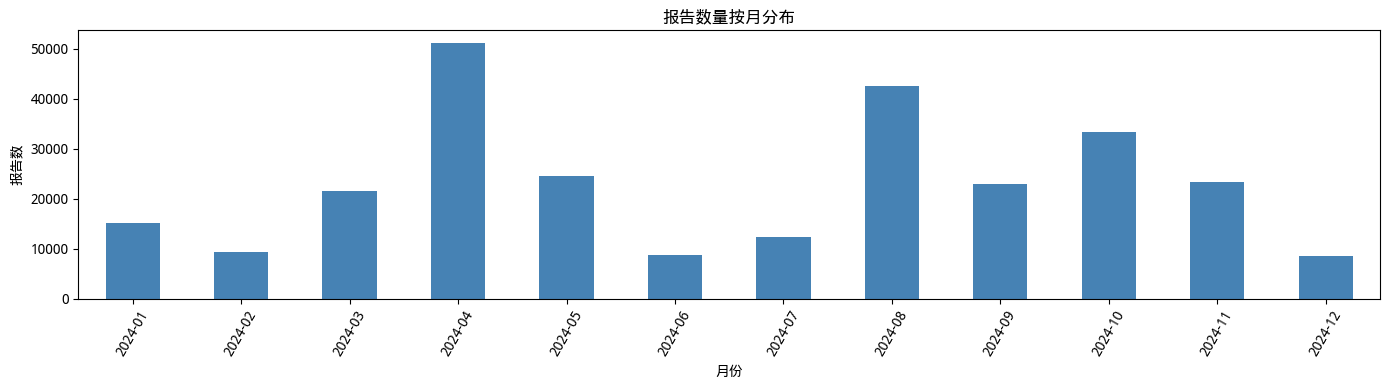

In [7]:
# ============================================================
# 3. 时间维度 CREATE_DATE
# ============================================================
dt = pd.to_datetime(df["CREATE_DATE"], errors="coerce")
print("能否全部解析为日期:", bool(dt.notna().all()), "| 解析失败行数:", int(dt.isna().sum()))
print("时间范围:", dt.min(), "→", dt.max())
print("跨度天数:", (dt.max() - dt.min()).days)
print("不同日期数:", dt.nunique())

monthly = dt.dt.to_period("M").value_counts().sort_index()
print("\n按月报告数：")
print(monthly)

plt.figure(figsize=(14, 4))
monthly.plot(kind="bar", color="steelblue")
plt.title("报告数量按月分布")
plt.ylabel("报告数")
plt.xlabel("月份")
plt.xticks(rotation=60)
plt.tight_layout()
plt.show()


## 4. 文本字段（TITLE / CONTENT）


TITLE：无缺失 = True | 长度 min/中位/均值/max = 3 / 28.0 / 29.2 / 140

CONTENT：非空 230004 / 273409 条，缺失 43405 条 (15.88%)
CONTENT(非空) 长度：min/中位/均值/max = 68 / 1164.0 / 1277.5 / 12809
CONTENT 长度分位数：
0.00       68.0
0.25      996.0
0.50     1164.0
0.75     1386.0
0.90     1832.0
0.99     2901.0
1.00    12809.0
Name: CONTENT, dtype: float64


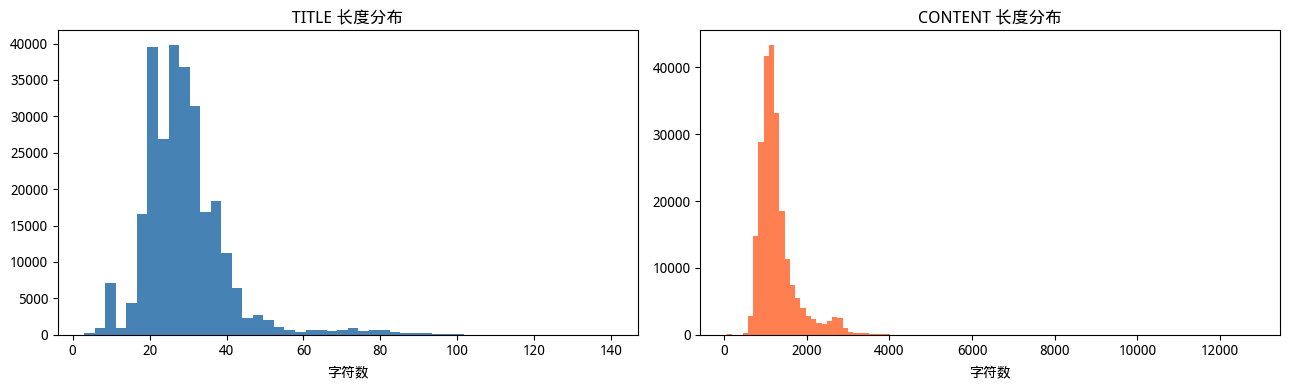

In [8]:
# ============================================================
# 4.1 文本字段长度分布
# ============================================================
title_len = df["TITLE"].str.len()
print("TITLE：无缺失 =", bool(df["TITLE"].notna().all()),
      "| 长度 min/中位/均值/max = %d / %.1f / %.1f / %d" % (
          title_len.min(), title_len.median(), title_len.mean(), title_len.max()))

content_non_null = df["CONTENT"].dropna()
print("\nCONTENT：非空 %d / %d 条，缺失 %d 条 (%.2f%%)" % (
    content_non_null.shape[0], df.shape[0],
    int(df["CONTENT"].isna().sum()), df["CONTENT"].isna().mean() * 100))

clen = content_non_null.str.len()
print("CONTENT(非空) 长度：min/中位/均值/max = %d / %.1f / %.1f / %d" % (
    clen.min(), clen.median(), clen.mean(), clen.max()))
print("CONTENT 长度分位数：")
print(clen.quantile([0.0, 0.25, 0.5, 0.75, 0.9, 0.99, 1.0]))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(title_len, bins=50, color="steelblue")
axes[0].set_title("TITLE 长度分布")
axes[0].set_xlabel("字符数")
axes[1].hist(clen, bins=100, color="coral")
axes[1].set_title("CONTENT 长度分布")
axes[1].set_xlabel("字符数")
plt.tight_layout()
plt.show()


In [9]:
# ============================================================
# 4.2 文本重复情况 与 样本查看
# ============================================================
print("TITLE  唯一值 %d / 总行数 %d，重复标题行数 = %d" % (
    df["TITLE"].nunique(), len(df), int(df["TITLE"].duplicated().sum())))
print("CONTENT 唯一值(非空) %d / 非空条数 %d，重复正文条数 = %d" % (
    content_non_null.nunique(), len(content_non_null),
    int(content_non_null.duplicated().sum())))

# 把标题里的“股票名：”前缀去掉，看最常出现的报告主体
title_core = df["TITLE"].str.replace(r"^[^：:]{1,20}[：:]", "", regex=True)
print("\n最常见的标题主体 Top 15：")
print(title_core.value_counts().head(15).to_string())

longest_idx = clen.idxmax()
shortest_idx = clen.idxmin()
print("\n--- 最长正文样本 (index=%d, %d 字符) ---" % (longest_idx, clen[longest_idx]))
print("标题:", df.loc[longest_idx, "TITLE"])
print("正文前 1500 字:")
print(df.loc[longest_idx, "CONTENT"][:1500])
print("\n--- 最短正文样本 (index=%d, %d 字符) ---" % (shortest_idx, clen[shortest_idx]))
print("标题:", df.loc[shortest_idx, "TITLE"])
print("正文(repr):", repr(df.loc[shortest_idx, "CONTENT"]))


TITLE  唯一值 80691 / 总行数 273409，重复标题行数 = 192718


CONTENT 唯一值(非空) 77061 / 非空条数 230004，重复正文条数 = 152943



最常见的标题主体 Top 15：
中信证券每日盈利预测                                              6651
申万宏源晨会报告                                                 312
食品饮料行业周报                                                 167
低仓位、24Q1业绩增长和品类驱动医药行情——2023年度和2024年一季度医药业绩总结和投资展望        124
多地发布明年国补工作通知，造纸行业景气度回升                                   123
绿证核发及交易新规发布，欧亚气价高位回落——申万公用环保周报（24／09／02～24／09／06）        123
ASCO摘要重点数据整理，2024年集采8号文解读                                116
10月工程机械出口额同比增长22％；聚焦工程机械、工业气体等——机械行业周报（2024年11月第3周）      114
周周谈之回顾一月、汽车销量更新——看好智能驾驶、机器人、商用车、低估值零部件，乘用车有望补库带来估值修复     106
地产利好政策大力加码；力推工程机械、出口链等——机械行业周报（2024年5月第3周）               102
中上游需求有望逐季向好，首选超跌兼顾成长优选标的                                 101
AI_Agent繁荣时代开启，科技内需迎新篇章——2025年计算机行业年度策略报告                 96
民用无人机行业长坡厚雪，产业升级和政策催化共促发展——低空经济系列之三                       94
年报预告结构性特征显著，继续推荐新域新质方向                                    93
拐点显现，涅槃重生——食品饮料行业2025年度策略                                 92

--- 最长正文样本 (index=129123, 12809 字符) ---
标题: Southern_Power_Grid：In

## 5. 分类字段取值分布


REPORT_TYPE  dtype=int64  唯一值数=6
25    202717
21     41756
22     16131
23     12502
26       213
24        90

ATTENTION  dtype=object  唯一值数=4
一般报告    238111
首次关注     18634
首份报告     15592
首次评级      1072

RELIABILITY  dtype=float64  唯一值数=6
NaN    231665
5.0     25582
9.0      7345
7.0      5566
8.0      3037
1.0       178
6.0        36

LANGUAGE  dtype=float64  唯一值数=2
0.0    224412
NaN     41756
1.0      7241

CURRENCY  dtype=float64  唯一值数=0
NaN    273409



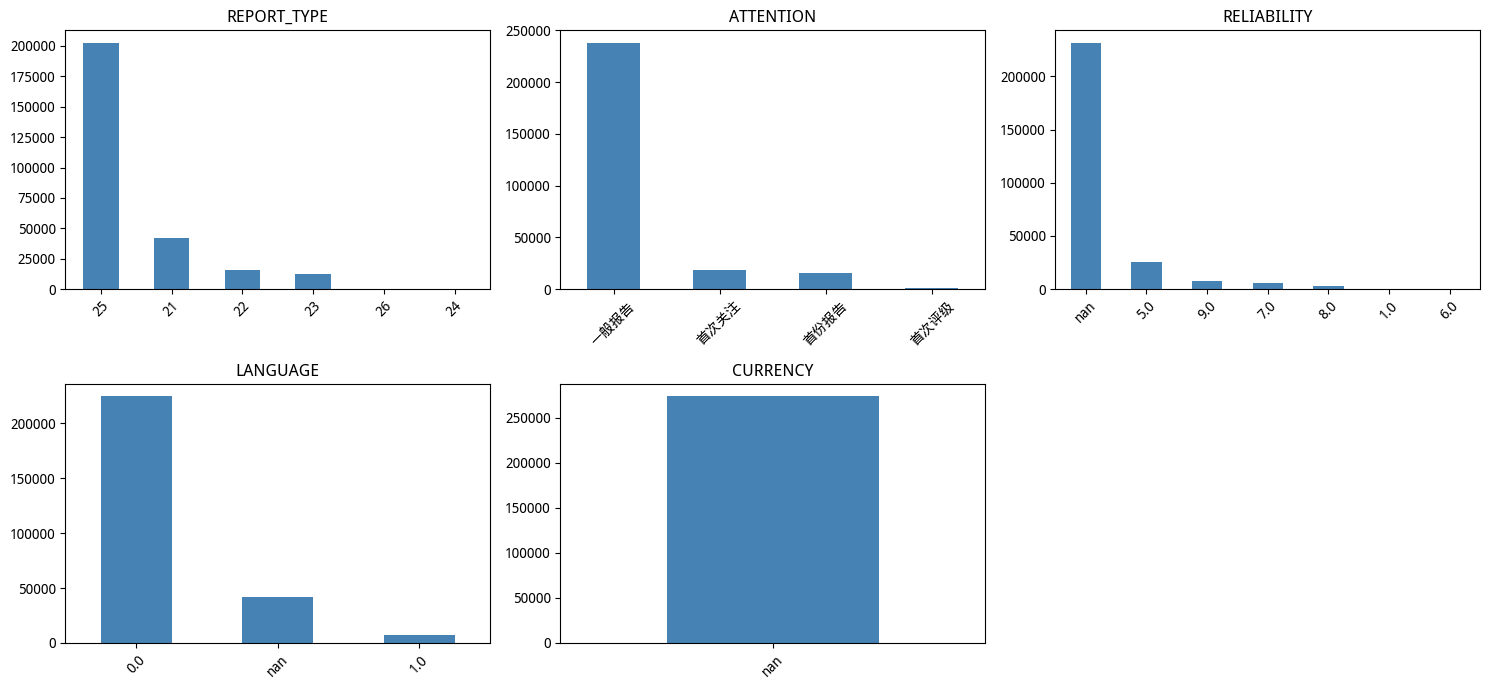

In [10]:
# ============================================================
# 5. 分类字段取值分布
# ============================================================
for c in cat_cols:
    print("=" * 70)
    print("%s  dtype=%s  唯一值数=%d" % (c, df[c].dtype, df[c].nunique(dropna=True)))
    print(df[c].value_counts(dropna=False).to_string())
    print()

fig, axes = plt.subplots(2, 3, figsize=(15, 7))
axes = axes.ravel()
for i, c in enumerate(cat_cols):
    df[c].value_counts(dropna=False).plot(kind="bar", ax=axes[i], color="steelblue")
    axes[i].set_title(c)
    axes[i].tick_params(axis="x", rotation=45)
axes[-1].axis("off")
plt.tight_layout()
plt.show()


## 6. 评级字段：编码 ↔ 文案对应关系


In [11]:
# ============================================================
# 6. 评级字段：编码 与 文案 的对应关系
# ============================================================
for cc, content_col in [("ORGAN_RATING_CODE", "ORGAN_RATING_CONTENT"),
                        ("GG_RATING_CODE", "GG_RATING_CONTENT")]:
    print("=" * 70)
    print(cc, "<->", content_col)
    mapping = (df[[cc, content_col]].groupby(cc)[content_col]
               .agg(lambda s: sorted(set(s))).sort_index())
    for codev, contents in mapping.items():
        print("  %-6s -> %s" % (codev, contents))
    print()

print("=" * 70)
print("评级文案取值分布：")
for content_col in ["ORGAN_RATING_CONTENT", "GG_RATING_CONTENT"]:
    print("\n", content_col)
    print(df[content_col].value_counts(dropna=False).to_string())


ORGAN_RATING_CODE <-> ORGAN_RATING_CONTENT
  0      -> ['无']
  13     -> ['中性']
  21     -> ['强烈推荐']
  26     -> ['中性']
  35     -> ['中性']
  38     -> ['买入']
  39     -> ['增持']
  40     -> ['中性']
  56     -> ['增持']
  62     -> ['买入']
  63     -> ['持有']
  74     -> ['中性']
  79     -> ['增持']
  101    -> ['增持']
  110    -> ['增持']
  113    -> ['谨慎增持']
  116    -> ['增持']
  122    -> ['增持']
  136    -> ['增持']
  137    -> ['中性']
  142    -> ['持有']
  146    -> ['买入']
  151    -> ['买入']
  161    -> ['增持']
  169    -> ['买入']
  170    -> ['增持']
  175    -> ['买入']
  177    -> ['买入']
  184    -> ['买入']
  185    -> ['增持']
  205    -> ['Overweight']
  225    -> ['中性']
  256    -> ['买入']
  272    -> ['买入']
  273    -> ['增持']
  277    -> ['强烈推荐']
  278    -> ['推荐']
  308    -> ['推荐']
  312    -> ['持有']
  314    -> ['买入']
  322    -> ['买入']
  323    -> ['增持']
  326    -> ['买入']
  327    -> ['中性']
  329    -> ['增持']
  331    -> ['增持']
  342    -> ['中性']
  343    -> ['增持']
  347    -> ['推荐']
  362    -> [

## 7. 机构 / 分析师 / 股票分布


In [12]:
# ============================================================
# 7. 机构 / 分析师 / 股票分布
# ============================================================
print("机构数 =", df["ORGAN_NAME"].nunique())
print("Top20 机构：")
print(df["ORGAN_NAME"].value_counts().head(20).to_string())

print("\n股票代码数 =", df["STOCK_CODE"].nunique(), "| 股票名称数 =", df["STOCK_NAME"].nunique())
print("Top20 股票(名称) 报告数：")
print(df["STOCK_NAME"].value_counts().head(20).to_string())

# 分析师拆分统计（AUTHOR_NAME 以逗号分隔）
authors = df["AUTHOR_NAME"].dropna().str.split(",", expand=False).explode().str.strip()
print("\n分析师去重人数 =", authors.nunique())
print("Top20 分析师：")
print(authors.value_counts().head(20).to_string())


机构数 = 94
Top20 机构：
国泰君安      11587
华泰证券      10621
申万宏源证券    10229
浙商证券       9791
东吴证券       9183
中金         8851
长江证券       8366
中信证券       8347
国信证券       8210
中信建投       8030
广发证券       7564
民生证券       7554
华泰香港       6909
招商证券       6780
天风证券       6561
华创证券       6365
开源证券       6320
方正证券       6037
海通证券       5971
兴业证券       5642

股票代码数 = 3422 | 股票名称数 = 3441
Top20 股票(名称) 报告数：
比亚迪     1081
贵州茅台     997
东鹏饮料     812
五粮液      760
长城汽车     752
宁德时代     750
今世缘      738
青岛啤酒     680
山西汾酒     679
盐津铺子     674
长安汽车     666
石头科技     661
劲仔食品     640
中炬高新     638
万华化学     601
华利集团     588
爱美客      588
北方华创     563
重庆啤酒     562
拓普集团     560



分析师去重人数 = 4619
Top20 分析师：
王华君    2812
邱世梁    2736
曾朵红    2007
无      1980
谢春生    1774
樊俊豪    1629
李思扬    1440
何家恺    1431
杨林     1430
孙海洋    1388
倪正洋    1344
王玮嘉    1343
邬博华    1322
黄波     1300
李雅琳    1255
王泽华    1252
宋涛     1237
王涛     1232
代雯     1208
方晏荷    1105


## 8. 数值字段（预测值 & 价格）分布


In [13]:
# ============================================================
# 8.1 数值字段统计描述
# ============================================================
num_cols = forecast_cols + price_cols
desc = df[num_cols].describe().T
desc["missing_rate"] = df[num_cols].isna().mean().round(4)
desc


,count,mean,std,min,25%,50%,75%,max,missing_rate
FORECAST_OR,242544.0,5.816060e+06,2.111627e+07,0.000,344300.000,928900.00,3031750.00,3.857471e+08,0.1129
FORECAST_OP,29823.0,1.205309e+06,3.885012e+06,-528400.000,125400.000,303856.00,786100.00,7.274010e+07,0.8909
FORECAST_TP,214261.0,7.783597e+05,2.821233e+06,-3940992.000,48100.000,128100.00,398100.00,5.246550e+07,0.2163
FORECAST_NP,270698.0,6.109926e+05,2.287453e+06,-2070700.000,41089.500,106000.00,313500.00,4.274210e+07,0.0099
FORECAST_EPS,272007.0,2.335171e+00,5.324888e+00,-6.859,0.724,1.27,2.30,9.801000e+01,0.0051
FORECAST_DPS,72432.0,8.073287e-01,3.264512e+00,0.000,0.110,0.32,0.70,1.348200e+02,0.7351
FORECAST_RD,63833.0,2.182534e+00,2.682425e+00,0.000,0.500,1.69,3.24,2.536000e+02,0.7665
FORECAST_PE,214112.0,2.705966e+01,4.032120e+02,0.073,11.200,15.80,22.90,1.350918e+05,0.2169
FORECAST_ROE,230718.0,1.361030e+01,3.344153e+01,-8022.700,9.200,13.00,17.40,6.374400e+03,0.1561
FORECAST_EV_EBITDA,169766.0,1.677696e+01,9.805359e+01,-60.200,6.790,10.00,15.50,1.666900e+04,0.3791


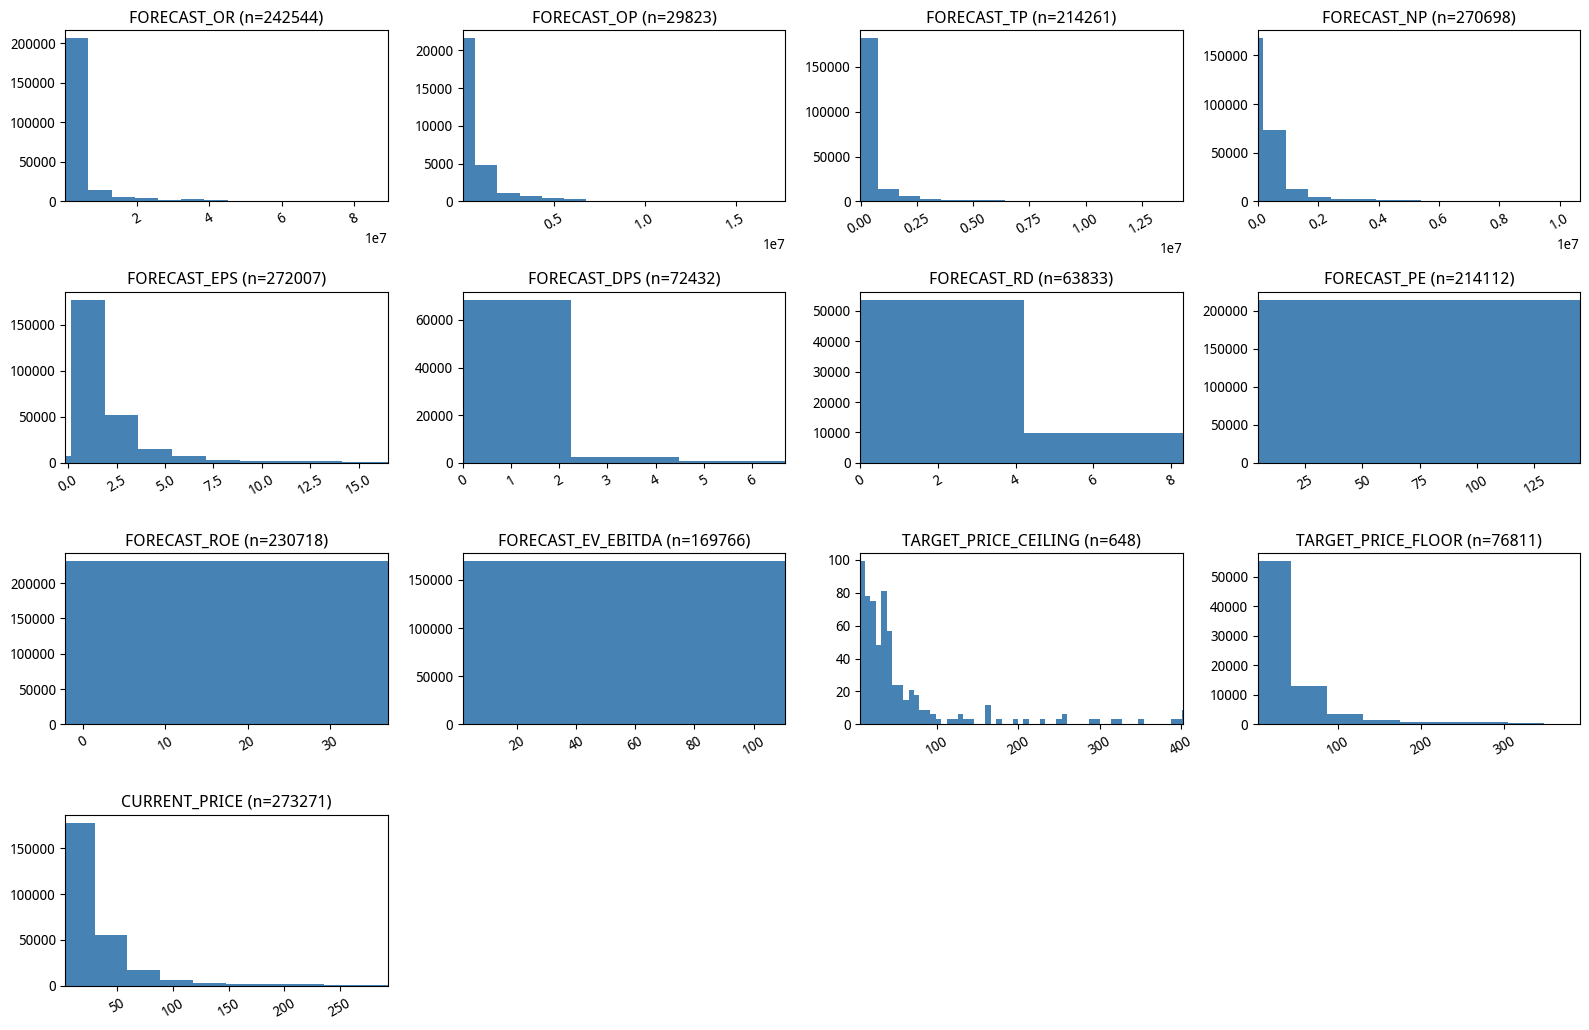

In [14]:
# ============================================================
# 8.2 数值字段分布直方图（裁剪到 1%~99% 便于观察）
# ============================================================
ncols = len(num_cols)
nrow = int(np.ceil(ncols / 4))
fig, axes = plt.subplots(nrow, 4, figsize=(16, 2.6 * nrow))
axes = np.array(axes).ravel()
for i, c in enumerate(num_cols):
    s = df[c].dropna()
    if len(s) == 0:
        axes[i].set_title("%s (全空)" % c)
        axes[i].axis("off")
        continue
    lo, hi = s.quantile(0.01), s.quantile(0.99)
    if lo == hi:
        lo, hi = s.min(), s.max()
    axes[i].hist(s, bins=60, color="steelblue")
    axes[i].set_xlim(lo, hi)
    axes[i].set_title("%s (n=%d)" % (c, len(s)))
    axes[i].tick_params(axis="x", rotation=30)
for j in range(i + 1, len(axes)):
    axes[j].axis("off")
plt.tight_layout()
plt.show()


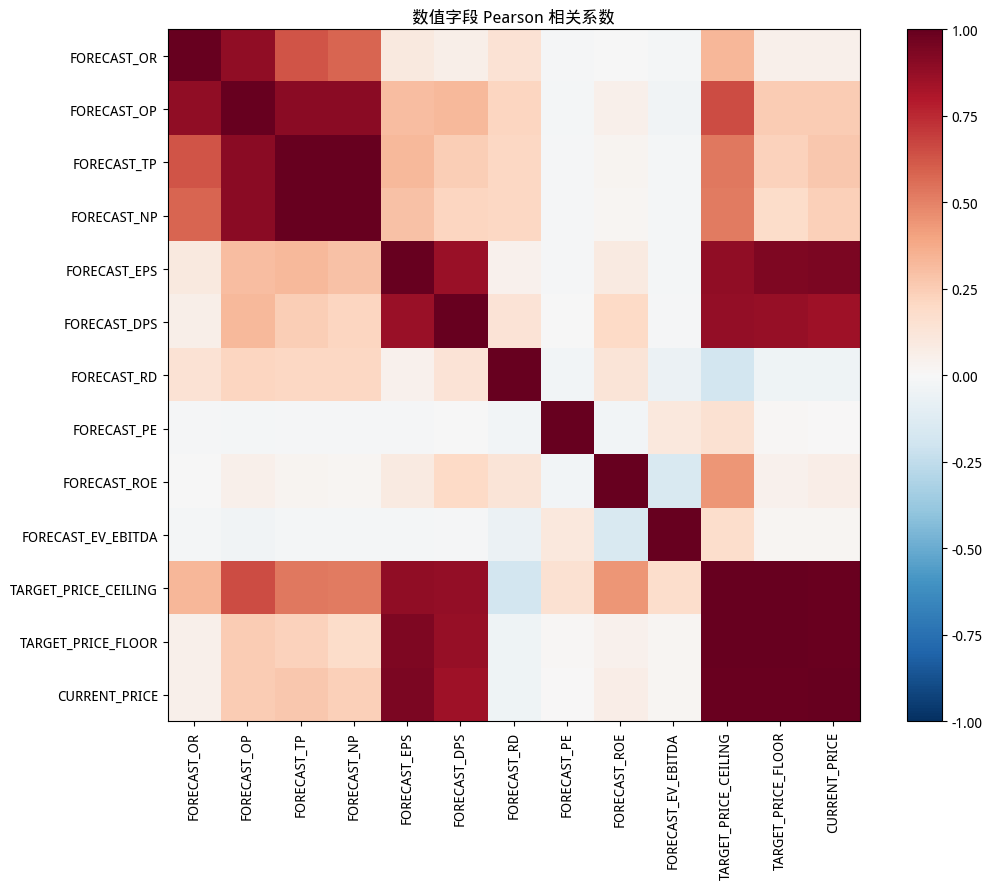

,FORECAST_OR,FORECAST_OP,FORECAST_TP,FORECAST_NP,FORECAST_EPS,FORECAST_DPS,FORECAST_RD,FORECAST_PE,FORECAST_ROE,FORECAST_EV_EBITDA,TARGET_PRICE_CEILING,TARGET_PRICE_FLOOR,CURRENT_PRICE
FORECAST_OR,1.00,0.89,0.63,0.58,0.10,0.06,0.15,-0.01,-0.00,-0.02,0.33,0.05,0.05
FORECAST_OP,0.89,1.00,0.90,0.90,0.31,0.33,0.21,-0.02,0.05,-0.03,0.65,0.25,0.26
FORECAST_TP,0.63,0.90,1.00,0.99,0.32,0.24,0.20,-0.01,0.02,-0.02,0.53,0.23,0.27
FORECAST_NP,0.58,0.90,0.99,1.00,0.29,0.21,0.20,-0.01,0.02,-0.02,0.52,0.18,0.24
FORECAST_EPS,0.10,0.31,0.32,0.29,1.00,0.87,0.04,-0.01,0.09,-0.02,0.89,0.93,0.94
FORECAST_DPS,0.06,0.33,0.24,0.21,0.87,1.00,0.14,-0.01,0.20,-0.01,0.88,0.87,0.84
FORECAST_RD,0.15,0.21,0.20,0.20,0.04,0.14,1.00,-0.02,0.13,-0.06,-0.19,-0.05,-0.04
FORECAST_PE,-0.01,-0.02,-0.01,-0.01,-0.01,-0.01,-0.02,1.00,-0.03,0.10,0.15,0.01,0.00
FORECAST_ROE,-0.00,0.05,0.02,0.02,0.09,0.20,0.13,-0.03,1.00,-0.15,0.44,0.05,0.07
FORECAST_EV_EBITDA,-0.02,-0.03,-0.02,-0.02,-0.02,-0.01,-0.06,0.10,-0.15,1.00,0.17,0.02,0.02


In [15]:
# ============================================================
# 8.3 数值字段相关性
# ============================================================
corr = df[num_cols].corr()
fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=90)
ax.set_yticks(range(len(corr.columns)))
ax.set_yticklabels(corr.columns)
fig.colorbar(im, ax=ax, fraction=0.046)
plt.title("数值字段 Pearson 相关系数")
plt.tight_layout()
plt.show()
corr.round(2)


## 9. 字段交叉关系


In [16]:
# ============================================================
# 9.1 报告类型 × 关注标签 × 是否有正文
# ============================================================
print("报告类型(REPORT_TYPE) 取值分布：")
print(df["REPORT_TYPE"].value_counts(dropna=False).to_string())
print("\n关注标签(ATTENTION) 取值分布：")
print(df["ATTENTION"].value_counts(dropna=False).to_string())
print("\n报告类型 × 关注标签 交叉表：")
print(pd.crosstab(df["REPORT_TYPE"], df["ATTENTION"], margins=True))

tmp = df.copy()
tmp["HAS_CONTENT"] = tmp["CONTENT"].notna()
print("\n报告类型 × 是否有正文 交叉表：")
print(pd.crosstab(tmp["REPORT_TYPE"], tmp["HAS_CONTENT"], margins=True))


报告类型(REPORT_TYPE) 取值分布：
25    202717
21     41756
22     16131
23     12502
26       213
24        90

关注标签(ATTENTION) 取值分布：
一般报告    238111
首次关注     18634
首份报告     15592
首次评级      1072

报告类型 × 关注标签 交叉表：
ATTENTION      一般报告   首份报告   首次关注  首次评级     All
REPORT_TYPE                                    
21            41756      0      0     0   41756
22             8116   2419   5290   306   16131
23             3688   2505   5983   326   12502
24               75      9      6     0      90
25           184476  10659   7145   437  202717
26                0      0    210     3     213
All          238111  15592  18634  1072  273409

报告类型 × 是否有正文 交叉表：


HAS_CONTENT  False    True     All
REPORT_TYPE                       
21           41748       8   41756
22              22   16109   16131
23             226   12276   12502
24               3      87      90
25            1381  201336  202717
26              25     188     213
All          43405  230004  273409


REPORT_YEAR × REPORT_QUARTER 交叉表（报告对应的财报期）：
REPORT_QUARTER  1.0  2.0  3.0     4.0     All
REPORT_YEAR                                  
2023.0            0    0    0   12784   12784
2024.0          316  819  816   93644   95595
2025.0           27    1    0   91517   91545
2026.0            0    0    0   72960   72960
2027.0            0    0    0      15      15
2028.0            0    0    0       8       8
2029.0            0    0    0       5       5
2030.0            0    0    0       5       5
2031.0            0    0    0       3       3
2032.0            0    0    0       3       3
2033.0            0    0    0       2       2
All             343  820  816  270946  272925


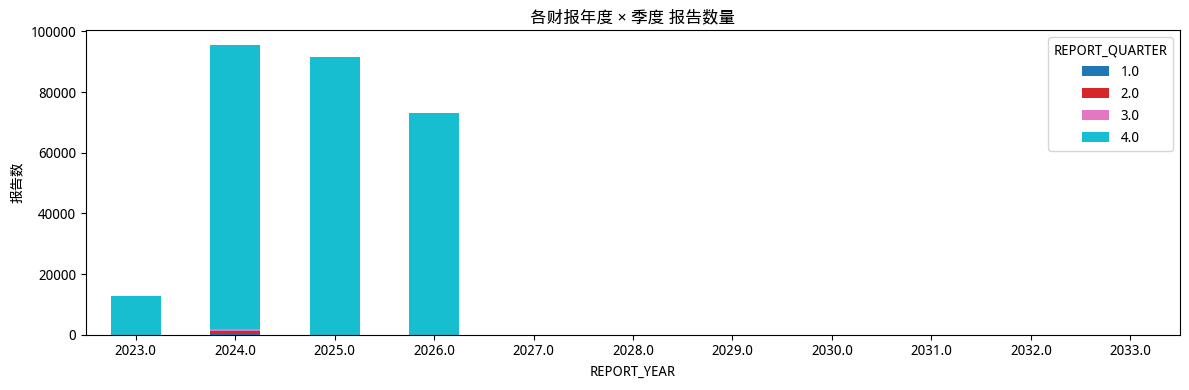

In [17]:
# ============================================================
# 9.2 财报年度 × 季度 分布
# ============================================================
print("REPORT_YEAR × REPORT_QUARTER 交叉表（报告对应的财报期）：")
print(pd.crosstab(df["REPORT_YEAR"], df["REPORT_QUARTER"], margins=True))

fig, ax = plt.subplots(figsize=(12, 4))
ct = pd.crosstab(df["REPORT_YEAR"], df["REPORT_QUARTER"])
ct.plot(kind="bar", stacked=True, ax=ax, colormap="tab10")
ax.set_title("各财报年度 × 季度 报告数量")
ax.set_ylabel("报告数")
ax.set_xlabel("REPORT_YEAR")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 10. 原始数据抽样查看


In [18]:
# ============================================================
# 10. 原始数据抽样查看（逐字段打印若干条完整记录）
# ============================================================
sample = df.sample(n=3, random_state=42)

for i, (idx, row) in enumerate(sample.iterrows(), 1):
    print("=" * 80)
    print("样本 %d / 3   (原始 index=%d, ID=%s)" % (i, idx, row["ID"]))
    print("-" * 80)
    for col in df.columns:
        val = row[col]
        if col == "CONTENT" and isinstance(val, str) and len(val) > 800:
            val = val[:800] + "  ......[截断]"
        print("%-24s : %s" % (col, val))
    print()


样本 1 / 3   (原始 index=41781, ID=3882762)
--------------------------------------------------------------------------------
ID                       : 3882762
STOCK_CODE               : 300127
STOCK_NAME               : 银河磁体
TITLE                    : 银河磁体：稀土价格波动，公司业绩环比下滑
CONTENT                  :         23年公司归母净利润同比下滑-6.10%，维持持有评级

        公司23年实现营业收入8.24亿元，yoy-16.95%；归母净利润1.61亿元，yoy-6.10%，23年稀土价格快速下跌对公司业绩形成较大影响。基于稀土原材料价格趋稳，下游需求回暖判断下，我们预计公司24-26年归母净利润分别为1.86/2.18/2.40亿元（前值24-25年分别2.09/2.30亿元）。可比公司24年Wind一致预期PE27.06X，给予公司24年27.06XPE，预计24年EPS为0.57元，目标价15.42元（前值16.52元），维持“持有”评级。

        原材料价格波动导致公司23Q4盈利能力下滑

        根据年报披露，公司2023年稀土永磁材料销量2856吨，yoy+8.59%。23年公司全年综合毛利率和净利率分别为32.21%/19.54%，yoy+4.54pct/+2.19pct。受四季度稀土原材料价格下跌过快影响，23Q4公司毛利率/净利率分别为23.99%/7.74%，qoq-8.88pct/-12.50pct。费用方面，公司23年合计期间费用率9.79%，yoy+2.34pct。其中公司23年销售/管理/分别为1.04%/4.47%，保持相对稳定。研发费用率达到6.45%，yoy+1.49pct。财务费率-2.17%，yoy+0.58pct主要系公司汇兑收益同比下降728.90万元。

        23年公司产品结构维持稳定，热压钕铁硼产品未来需求广阔

        根据年报信息，2023年公司粘结钕铁硼业务营收为7.46亿元

## 11. 结论摘要（自动汇总）


In [19]:
# ============================================================
# 11. 结论摘要（自动汇总）
# ============================================================
dt_all = pd.to_datetime(df["CREATE_DATE"], errors="coerce")
authors_all = df["AUTHOR_NAME"].dropna().str.split(",", expand=False).explode().str.strip()

lines = []
lines.append("总记录数: %d 行 × %d 列" % df.shape)
lines.append("时间范围: %s ~ %s (跨度 %d 天)" % (
    dt_all.min(), dt_all.max(), (dt_all.max() - dt_all.min()).days))
lines.append("股票: 代码 %d 个 / 名称 %d 个；机构 %d 家；分析师 %d 位" % (
    df["STOCK_CODE"].nunique(), df["STOCK_NAME"].nunique(),
    df["ORGAN_NAME"].nunique(), authors_all.nunique()))
lines.append("ID 唯一: %s；完全重复行: %d；去掉 ID 后重复: %d" % (
    df["ID"].is_unique, int(df.duplicated().sum()),
    int(df.drop(columns=["ID"]).duplicated().sum())))
lines.append("正文(CONTENT)缺失率: %.2f%%" % (df["CONTENT"].isna().mean() * 100))
lines.append("目标价上限缺失率: %.2f%%；币种(CURRENCY)缺失率: %.2f%%" % (
    df["TARGET_PRICE_CEILING"].isna().mean() * 100,
    df["CURRENCY"].isna().mean() * 100))
lines.append("财报期: 年度取值 %s；季度取值 %s" % (
    sorted(df["REPORT_YEAR"].dropna().unique().tolist()),
    sorted(df["REPORT_QUARTER"].dropna().unique().tolist())))
lines.append("报告类型取值: %s" % sorted(df["REPORT_TYPE"].dropna().unique().tolist()))
lines.append("关注标签取值: %s" % sorted(df["ATTENTION"].dropna().unique().tolist()))
lines.append("评级文案取值: %s" % sorted(df["ORGAN_RATING_CONTENT"].dropna().unique().tolist()))
print("\n".join(lines))


总记录数: 273409 行 × 32 列
时间范围: 2024-01-01 00:00:00 ~ 2024-12-31 00:00:00 (跨度 365 天)
股票: 代码 3422 个 / 名称 3441 个；机构 94 家；分析师 4619 位
ID 唯一: True；完全重复行: 0；去掉 ID 后重复: 0
正文(CONTENT)缺失率: 15.88%
目标价上限缺失率: 99.76%；币种(CURRENCY)缺失率: 100.00%
财报期: 年度取值 [2023.0, 2024.0, 2025.0, 2026.0, 2027.0, 2028.0, 2029.0, 2030.0, 2031.0, 2032.0, 2033.0]；季度取值 [1.0, 2.0, 3.0, 4.0]
报告类型取值: [21, 22, 23, 24, 25, 26]
关注标签取值: ['一般报告', '首份报告', '首次关注', '首次评级']
评级文案取值: ['BUY', 'Buy', 'HOLD', 'Neutral', 'OUTPERFORM', 'OVERWEIGHT', 'Outperform', 'Overweight', '中性', '买入', '买进', '优于大市', '区间操作', '卖出', '增持', '强于大市', '强推', '强烈推荐', '持有', '推荐', '无', '谨慎增持', '谨慎推荐', '跑赢行业']


## 12. 一致预期 / 预测修正 提取

基于前面探明的粒度（一行 = 某机构对某股票某财报期的一次预测），统一对缺失率 < 50% 的 `forecast_cols + price_cols` 提取三类产物：

1. **A. 一致预期表**：`(STOCK_CODE, FY)` → count / median / mean / std / min / max
2. **B. 一致预期修正时间序列**：`(STOCK_CODE, FY, 月份)` → median 走势 + 环比变化% + 首末变化
3. **C. 上调/下调标签**：首月→末月一致预期变化（`up/down/flat`），以及机构自身多次修正方向

> `REPORT_YEAR` 即财报年度 FY（几乎全为 Q4=全年口径）；`CURRENT_PRICE` 是当前价而非预测，其"一致预期"实为报告时点价格序列，仅作参考。


In [20]:
# ============================================================
# 12.0 配置：确定可用字段、定义上调/下调判定
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

cand_cols = forecast_cols + price_cols
miss = df[cand_cols].isna().mean()
eligible = [c for c in cand_cols if miss[c] < 0.5]
excluded = [c for c in cand_cols if miss[c] >= 0.5]
print("缺失率 < 50% 的字段（参与提取）:")
print((miss[eligible] * 100).round(2).sort_values().to_string())
print("\n被排除（缺失率 >= 50%）:")
print((miss[excluded] * 100).round(2).sort_values().to_string())

THR = 0.01  # 相对变化幅度 <= 1% 记为 flat

def rev_label(first, last):
    if pd.isna(first) or pd.isna(last):
        return None
    diff = last - first
    rel = diff / first if first != 0 else None
    if rel is None:
        return "up" if diff > 0 else ("down" if diff < 0 else "flat")
    if rel > THR:
        return "up"
    if rel < -THR:
        return "down"
    return "flat"


缺失率 < 50% 的字段（参与提取）:
CURRENT_PRICE          0.05
FORECAST_EPS           0.51
FORECAST_NP            0.99
FORECAST_OR           11.29
FORECAST_ROE          15.61
FORECAST_TP           21.63
FORECAST_PE           21.69
FORECAST_EV_EBITDA    37.91

被排除（缺失率 >= 50%）:
TARGET_PRICE_FLOOR      71.91
FORECAST_DPS            73.51
FORECAST_RD             76.65
FORECAST_OP             89.09
TARGET_PRICE_CEILING    99.76


### A. 一致预期表：(STOCK_CODE, FY)


In [21]:
# ============================================================
# A. 一致预期表
# ============================================================
consensus = {}
for col in eligible:
    d = df.dropna(subset=[col, "REPORT_YEAR"])
    g = d.groupby(["STOCK_CODE", "STOCK_NAME", "REPORT_YEAR"])[col]
    consensus[col] = g.agg(["count", "median", "mean", "std", "min", "max"]).reset_index()
    print("%-22s 组合数=%d" % (col, len(consensus[col])))

print("\n示例：FORECAST_NP 一致预期表（覆盖最多的前 10 组）")
print(consensus["FORECAST_NP"].sort_values("count", ascending=False).head(10).round(2).to_string(index=False))


FORECAST_OR            组合数=11978


FORECAST_TP            组合数=11525


FORECAST_NP            组合数=12171


FORECAST_EPS           组合数=12163


FORECAST_PE            组合数=11338


FORECAST_ROE           组合数=11847


FORECAST_EV_EBITDA     组合数=10618
CURRENT_PRICE          组合数=12203

示例：FORECAST_NP 一致预期表（覆盖最多的前 10 组）
 STOCK_CODE STOCK_NAME  REPORT_YEAR  count      median        mean       std        min         max
       2594        比亚迪       2024.0    370  3830050.00  3817851.69 232357.54 3163205.00  5168943.00
       2594        比亚迪       2025.0    361  4791300.00  4845403.13 448678.51 3621701.00  6589840.00
     600519       贵州茅台       2024.0    340  8720000.00  8710801.74 108589.20 8221200.00  9260690.18
     600519       贵州茅台       2025.0    331 10086800.00  9967884.12 308998.59 9201400.00 10685218.49
       2594        比亚迪       2026.0    283  5795500.00  5859938.21 644687.11 3947259.00  8238700.00
     605499       东鹏饮料       2024.0    275   285200.00   288668.84  25437.07  245300.00   348408.71
     600519       贵州茅台       2026.0    272 11410851.00 11247058.13 623852.44 7473120.71 12311900.00
     605499       东鹏饮料       2025.0    267   364700.00   370144.36  40782.93  301100.00   474800.00

### B. 一致预期修正时间序列：(STOCK_CODE, FY, 月份)


FORECAST_OR            首末组合数=11978


FORECAST_TP            首末组合数=11525


FORECAST_NP            首末组合数=12171


FORECAST_EPS           首末组合数=12163


FORECAST_PE            首末组合数=11338


FORECAST_ROE           首末组合数=11847


FORECAST_EV_EBITDA     首末组合数=10618


CURRENT_PRICE          首末组合数=12203

覆盖最多的组合: 比亚迪 (2594) FY2024.0
     YM  count    median  mom_pct
2024-01     34 4078450.0      NaN
2024-02     16 4012915.0    -1.61
2024-03     38 3869300.0    -3.58
2024-04     34 3749100.0    -3.11
2024-05     38 3666750.0    -2.20
2024-06     32 3701000.0     0.93
2024-07     28 3816815.5     3.13
2024-08     45 3795000.0    -0.57
2024-09     31 3806000.0     0.29
2024-10     27 3873800.0     1.78
2024-11     33 3850969.0    -0.59
2024-12     14 3946300.0     2.48


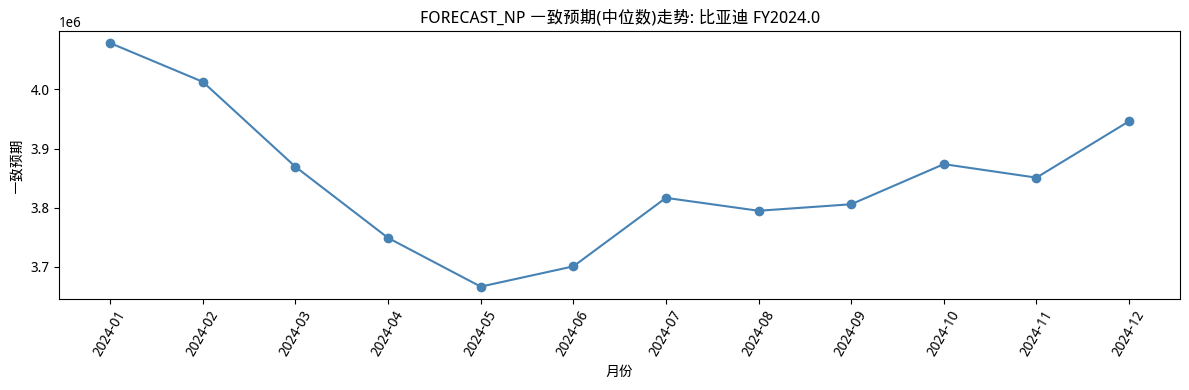


全市场 FORECAST_NP 首末变化标签分布:
down    6861
flat    3086
up      2224


In [22]:
# ============================================================
# B. 一致预期修正时间序列 + 首末变化
# ============================================================
ts = {}
first_last = {}
for col in eligible:
    d = df.dropna(subset=[col, "REPORT_YEAR"]).copy()
    d["YM"] = pd.to_datetime(d["CREATE_DATE"]).dt.to_period("M")
    m = (d.groupby(["STOCK_CODE", "STOCK_NAME", "REPORT_YEAR", "YM"])[col]
          .agg(["count", "median"]).reset_index()
          .sort_values(["STOCK_CODE", "REPORT_YEAR", "YM"]))
    m["mom_pct"] = m.groupby(["STOCK_CODE", "REPORT_YEAR"])["median"].pct_change() * 100
    ts[col] = m

    fl = (m.groupby(["STOCK_CODE", "STOCK_NAME", "REPORT_YEAR"])
           .agg(first=("median", "first"), last=("median", "last"), n_months=("YM", "nunique"))
           .reset_index())
    fl["diff"] = fl["last"] - fl["first"]
    fl["chg_pct"] = fl.apply(lambda r: (r["last"] / r["first"] - 1) * 100 if r["first"] != 0 else np.nan, axis=1)
    fl["label"] = fl.apply(lambda r: rev_label(r["first"], r["last"]), axis=1)
    first_last[col] = fl
    print("%-22s 首末组合数=%d" % (col, len(fl)))

# 展示覆盖最多的 (股票, FY) 的 NP 月度一致预期走势
ex = ts["FORECAST_NP"]
cov = ex.groupby(["STOCK_CODE", "STOCK_NAME", "REPORT_YEAR"])["count"].sum()
code_ex, name_ex, yr_ex = cov.idxmax()
view = ex[(ex["STOCK_CODE"] == code_ex) & (ex["REPORT_YEAR"] == yr_ex)].copy()
print("\n覆盖最多的组合: %s (%s) FY%s" % (name_ex, code_ex, yr_ex))
print(view[["YM", "count", "median", "mom_pct"]].round(2).to_string(index=False))

plt.figure(figsize=(12, 4))
plt.plot(view["YM"].astype(str), view["median"], marker="o", color="steelblue")
plt.title("FORECAST_NP 一致预期(中位数)走势: %s FY%s" % (name_ex, yr_ex))
plt.xlabel("月份")
plt.ylabel("一致预期")
plt.xticks(rotation=60)
plt.tight_layout()
plt.show()

print("\n全市场 FORECAST_NP 首末变化标签分布:")
print(first_last["FORECAST_NP"]["label"].value_counts(dropna=False).to_string())


### C. 上调/下调标签：机构自身多次修正


In [23]:
# ============================================================
# C. 机构层面自身修正方向（同一机构对同一股票+FY 的多次更新）
# ============================================================
org_rev = {}
for col in eligible:
    d = df.dropna(subset=[col, "REPORT_YEAR"]).copy()
    d["CREATE_DATE"] = pd.to_datetime(d["CREATE_DATE"])
    d = d.sort_values("CREATE_DATE")
    first = d.groupby(["STOCK_CODE", "REPORT_YEAR", "ORGAN_NAME"])[col].first()
    last = d.groupby(["STOCK_CODE", "REPORT_YEAR", "ORGAN_NAME"])[col].last()
    cnt = d.groupby(["STOCK_CODE", "REPORT_YEAR", "ORGAN_NAME"]).size()
    ndates = d.groupby(["STOCK_CODE", "REPORT_YEAR", "ORGAN_NAME"])["CREATE_DATE"].nunique()
    fl = pd.DataFrame({"first": first, "last": last, "count": cnt, "n_dates": ndates}).reset_index()
    fl = fl[fl["n_dates"] >= 2].copy()
    fl["diff"] = fl["last"] - fl["first"]
    fl["chg_pct"] = fl.apply(lambda r: (r["last"] / r["first"] - 1) * 100 if r["first"] != 0 else np.nan, axis=1)
    fl["label"] = fl.apply(lambda r: rev_label(r["first"], r["last"]), axis=1)
    org_rev[col] = fl
    print("%-22s 机构修正组数(>=2次)=%d | 分布=%s" % (
        col, len(fl), fl["label"].value_counts(dropna=False).to_dict()))


FORECAST_OR            机构修正组数(>=2次)=63627 | 分布={'down': 35201, 'flat': 17124, 'up': 11302}


FORECAST_TP            机构修正组数(>=2次)=56836 | 分布={'down': 33209, 'up': 12376, 'flat': 11251}


FORECAST_NP            机构修正组数(>=2次)=67635 | 分布={'down': 39253, 'up': 14455, 'flat': 13927}


FORECAST_EPS           机构修正组数(>=2次)=67477 | 分布={'down': 41655, 'up': 13343, 'flat': 12479}


FORECAST_PE            机构修正组数(>=2次)=56267 | 分布={'up': 37197, 'down': 16363, 'flat': 2707}


FORECAST_ROE           机构修正组数(>=2次)=61265 | 分布={'down': 34105, 'up': 15862, 'flat': 11298}


FORECAST_EV_EBITDA     机构修正组数(>=2次)=44890 | 分布={'up': 28047, 'down': 14253, 'flat': 2590}


CURRENT_PRICE          机构修正组数(>=2次)=67667 | 分布={'up': 33636, 'down': 31372, 'flat': 2659}


### D. 使用示例：查单只股票各字段


In [24]:
# ============================================================
# D. 使用示例：查看单只股票(比亚迪=2594) FY2024 各字段结果
# ============================================================
code_q = 2594
yr_q = 2024.0
for col in eligible:
    fl = first_last[col]
    row = fl[(fl["STOCK_CODE"] == code_q) & (fl["REPORT_YEAR"] == yr_q)]
    if len(row):
        r = row.iloc[0]
        chg_s = ("%+.1f%%" % r["chg_pct"]) if pd.notna(r["chg_pct"]) else "N/A"
        print(f"{col:<22} first={r['first']:.4g} last={r['last']:.4g} chg={chg_s:>8} label={r['label']} months={r['n_months']}")

print("\n可用产物变量: consensus / ts / first_last / org_rev （均为 {列名: DataFrame} 字典）")


FORECAST_OR            first=8.311e+07 last=7.651e+07 chg=   -7.9% label=down months=12
FORECAST_TP            first=5.148e+06 last=4.848e+06 chg=   -5.8% label=down months=12
FORECAST_NP            first=4.078e+06 last=3.946e+06 chg=   -3.2% label=down months=12
FORECAST_EPS           first=14.01 last=13.56 chg=   -3.2% label=down months=12
FORECAST_PE            first=13.34 last=20.76 chg=  +55.6% label=up months=12
FORECAST_ROE           first=23.44 last=22.88 chg=   -2.4% label=down months=12
FORECAST_EV_EBITDA     first=6.275 last=7.64 chg=  +21.8% label=up months=12
CURRENT_PRICE          first=188.1 last=282.4 chg=  +50.2% label=up months=12

可用产物变量: consensus / ts / first_last / org_rev （均为 {列名: DataFrame} 字典）
